In [1]:
# Imports for the projects
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from scipy import stats

# Since we will be working with dollar amount, we will format to two decimal places
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 50)

print("All libraries loaded successfully.")
print(f"Analysis timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

All libraries loaded successfully.
Analysis timestamp: 2026-04-20 08:04:53


In [5]:
# Creating the dataset
data = {'quarter': ['2025Q1', '2025Q2', '2025Q3', '2026Q1'],
    'period_label': ['Q1 2025', 'Q2 2025', 'Q3 2025', 'Q1 2026'],
    # Net Interest Income — the spread PNC earns between loan yields and deposit costs
    # Rising NII = either more loans, higher rates on assets, or lower deposit costs
    'net_interest_income': [2826, 2974, 3016, 3198],

    # Noninterest Income — fee revenue: card, mortgage, Visa adjustments, service charges
    # More volatile than NII; sensitive to market conditions and one-time items
    'noninterest_income': [706, 782, 790, 770],

    # Noninterest Expense — operating costs: people, technology, occupancy, marketing
    # Finance teams track this closely against the efficiency ratio target
    'noninterest_expense': [1903, 1890, 1941, 2115],

    # Provision for Credit Losses — reserve build for expected loan defaults
    # Rises when economic outlook deteriorates; fell sharply Q1→Q2 2025 (macro improvement)
    'provision_for_credit_losses': [168, 83, 126, 124],

    # Segment Earnings — bottom-line net income for the Retail Banking segment
    'earnings': [1112, 1359, 1324, 1320],

    # Average Loans ($B) — the total interest-earning loan book for the quarter
    # Note: Q1 2026 jump reflects FirstBank acquisition (closed Jan 5, 2026)
    'avg_loans_billions': [95.6, 97.5, 96.9, 110.9],

    # Average Deposits ($B) — the funding base; higher deposits = lower borrowing costs
    # Q1 2026 increase driven by acquired FirstBank deposits
    'avg_deposits_billions': [245.1, 243.5, 243.3, 268.2],

    # Net Loan Charge-Offs ($M) — loans written off as uncollectable, net of recoveries
    'net_loan_charge_offs': [144, 120, 126, 118]
}

# Building the DataFrame
retail_raw = pd.DataFrame(data)

# Checking the shale of the data
print(f"Dataset shape: {retail_raw.shape[0]} quarters × {retail_raw.shape[1]} columns")
print("\nColumn data types:")
print(retail_raw.dtypes)
print("\nFirst 5 rows (preview):")
retail_raw.head()

Dataset shape: 4 quarters × 10 columns

Column data types:
quarter                         object
period_label                    object
net_interest_income              int64
noninterest_income               int64
noninterest_expense              int64
provision_for_credit_losses      int64
earnings                         int64
avg_loans_billions             float64
avg_deposits_billions          float64
net_loan_charge_offs             int64
dtype: object

First 5 rows (preview):


,quarter,period_label,net_interest_income,noninterest_income,noninterest_expense,provision_for_credit_losses,earnings,avg_loans_billions,avg_deposits_billions,net_loan_charge_offs
0,2025Q1,Q1 2025,2826,706,1903,168,1112,95.60,245.10,144
1,2025Q2,Q2 2025,2974,782,1890,83,1359,97.50,243.50,120
2,2025Q3,Q3 2025,3016,790,1941,126,1324,96.90,243.30,126
3,2026Q1,Q1 2026,3198,770,2115,124,1320,110.90,268.20,118


In [8]:
# Making sure there are no null values or duplicate values since this would produce the wrong variance
print("Null value check (zeros = clean data):")
print(retail_raw.isnull().sum())
print(f"\nDuplicate rows: {retail_raw.duplicated().sum()}")

# CDefining the columns
column_definitions = {
    'quarter':                     'Period identifier (YYYYQN format for sort order)',
    'period_label':                'Label for chart axes (For example: Q1 2025)',
    'net_interest_income':         'NII — core revenue: loan interest earned minus deposit interest paid ($M)',
    'noninterest_income':          'Fee income: service charges, mortgage, card fees, Visa adjustments ($M)',
    'noninterest_expense':         'Operating costs: personnel, technology, occupancy, marketing ($M)',
    'provision_for_credit_losses': 'Reserve build for expected loan losses — rises in stress environments ($M)',
    'earnings':                    'Segment net income after all costs and provisions ($M)',
    'avg_loans_billions':          'Average outstanding loan balance during the quarter ($B)',
    'avg_deposits_billions':       'Average deposit funding base during the quarter ($B)',
    'net_loan_charge_offs':        'Loans written off as uncollectable, net of recoveries ($M)'
}

print("\nColumn definitions:")
for col, definition in column_definitions.items():
    print(f"  {col:35s}: {definition}")

Null value check (zeros = clean data):
quarter                        0
period_label                   0
net_interest_income            0
noninterest_income             0
noninterest_expense            0
provision_for_credit_losses    0
earnings                       0
avg_loans_billions             0
avg_deposits_billions          0
net_loan_charge_offs           0
dtype: int64

Duplicate rows: 0

Column definitions:
  quarter                            : Period identifier (YYYYQN format for sort order)
  period_label                       : Label for chart axes (For example: Q1 2025)
  net_interest_income                : NII — core revenue: loan interest earned minus deposit interest paid ($M)
  noninterest_income                 : Fee income: service charges, mortgage, card fees, Visa adjustments ($M)
  noninterest_expense                : Operating costs: personnel, technology, occupancy, marketing ($M)
  provision_for_credit_losses        : Reserve build for expected loan losses 

In [9]:
# Cleaning and formatting the data

# Creating a copy of the original DF
retail = retail_raw.copy()

# Sorting ascending by quarter since with time-series calculations require this order of the sign of the variance would be wrong
retail = retail.sort_values('quarter').reset_index(drop=True)

# Making sure that all of the financial columns are numeric
financial_cols = [
    'net_interest_income', 'noninterest_income', 'noninterest_expense',
    'provision_for_credit_losses', 'earnings', 'avg_loans_billions',
    'avg_deposits_billions', 'net_loan_charge_offs'
]

for col in financial_cols:
    retail[col] = pd.to_numeric(
        retail[col].astype(str).str.replace('[$,]', '', regex=True),
        errors='coerce'
    )

# Total Revenue = NII + Noninterest Income (mirroring how PNC reports total revenue values)
retail['total_revenue'] = retail['net_interest_income'] + retail['noninterest_income']

# Efficiency Ratio = Noninterest Expense / Total Revenue × 100 (the lower this nmumber the better)
retail['efficiency_ratio'] = (
    retail['noninterest_expense'] / retail['total_revenue'] * 100
).round(1)

print("Data cleaning complete. Final column list:")
print(retail.columns.tolist())
print(f"\nQuarters in dataset (chronological):")
print(retail[['quarter', 'period_label']].to_string(index=False))

Data cleaning complete. Final column list:
['quarter', 'period_label', 'net_interest_income', 'noninterest_income', 'noninterest_expense', 'provision_for_credit_losses', 'earnings', 'avg_loans_billions', 'avg_deposits_billions', 'net_loan_charge_offs', 'total_revenue', 'efficiency_ratio']

Quarters in dataset (chronological):
quarter period_label
 2025Q1      Q1 2025
 2025Q2      Q2 2025
 2025Q3      Q3 2025
 2026Q1      Q1 2026


In [11]:
# Displaying the cleaned dataset
print("Cleaned dataset preview ($M unless noted):")
retail[[
    'period_label', 'net_interest_income', 'noninterest_income',
    'total_revenue', 'noninterest_expense', 'provision_for_credit_losses',
    'earnings', 'efficiency_ratio'
]]

Cleaned dataset preview ($M unless noted):


,period_label,net_interest_income,noninterest_income,total_revenue,noninterest_expense,provision_for_credit_losses,earnings,efficiency_ratio
0,Q1 2025,2826,706,3532,1903,168,1112,53.90
1,Q2 2025,2974,782,3756,1890,83,1359,50.30
2,Q3 2025,3016,790,3806,1941,126,1324,51.00
3,Q1 2026,3198,770,3968,2115,124,1320,53.30


In [12]:
# Variance Analysis

# We will use both QoQ (Quarter-over-Quarter) and  YoY (Year-over-Year) since QoQ is distorted by the fact that Q1 is fewer days and therefor distorted

# We will use a materiality threshold of ±5% since it is most common in financial reporting (percent — adjust to change flagging sensitivity)

MATERIALITY_THRESHOLD = 5.0

# Key metrics to analyze — these are the drivers a Retail Finance team monitors
key_metrics = [
    'net_interest_income',
    'noninterest_income',
    'total_revenue',
    'noninterest_expense',
    'provision_for_credit_losses',
    'earnings',
    'avg_loans_billions',
    'avg_deposits_billions'
]

variance_df = retail[['quarter', 'period_label'] + key_metrics].copy()

# Calculating QoQ VARIANCE using the Formula: (Current - Prior) / |Prior| × 100
# We use |Prior| to handle edge cases where the prior value is negative.
for metric in key_metrics:
    prior_qoq = variance_df[metric].shift(1)
    variance_df[f'{metric}_qoq_change'] = variance_df[metric] - prior_qoq
    variance_df[f'{metric}_qoq_pct'] = (
        (variance_df[metric] - prior_qoq) / prior_qoq.abs() * 100
    ).round(2)

# Calculating the YoY VARIANCE
# With 4 quarters in this dataset, YoY is only available for Q1 2026 vs Q1 2025.
for metric in key_metrics:
    prior_yoy = variance_df[metric].shift(4)
    variance_df[f'{metric}_yoy_change'] = variance_df[metric] - prior_yoy
    variance_df[f'{metric}_yoy_pct'] = (
        (variance_df[metric] - prior_yoy) / prior_yoy.abs() * 100
    ).round(2)

print("QoQ and YoY variance columns created.")
print(f"Total columns in variance_df: {len(variance_df.columns)}")
print("\nQoQ % changes (most recent quarter):")
latest_row = variance_df.iloc[-1]
for m in key_metrics:
    val = latest_row[f'{m}_qoq_pct']
    print(f"  {m:35s}: {val:+.2f}%" if not np.isnan(val) else f"  {m:35s}: N/A")

QoQ and YoY variance columns created.
Total columns in variance_df: 42

QoQ % changes (most recent quarter):
  net_interest_income                : +6.03%
  noninterest_income                 : -2.53%
  total_revenue                      : +4.26%
  noninterest_expense                : +8.96%
  provision_for_credit_losses        : -1.59%
  earnings                           : -0.30%
  avg_loans_billions                 : +14.45%
  avg_deposits_billions              : +10.23%


In [13]:
# Automating the comment generation so we can spend more time on the "why" rather than writing repetitive comments
def generate_commentary(metric_name, qoq_pct, yoy_pct, threshold=MATERIALITY_THRESHOLD):
    """Generate a plain-English variance explanation for any flagged metric."""
    commentary_parts = []
    clean_name = metric_name.replace('_', ' ').title()

    if pd.notnull(qoq_pct) and abs(qoq_pct) >= threshold:
        direction = 'increased' if qoq_pct > 0 else 'decreased'
        commentary_parts.append(
            f"{clean_name} {direction} {abs(qoq_pct):.1f}% QoQ — "
            f"exceeds the ±{threshold}% materiality threshold. "
            f"Investigate: rate environment, loan mix shifts, or seasonal factors."
        )

    if pd.notnull(yoy_pct) and abs(yoy_pct) >= threshold:
        direction = 'increased' if yoy_pct > 0 else 'decreased'
        commentary_parts.append(
            f"{clean_name} {direction} {abs(yoy_pct):.1f}% YoY — "
            f"year-over-year signal (seasonality-adjusted). "
            f"Review strategic initiatives, market share, and macro drivers."
        )

    return (
        ' | '.join(commentary_parts)
        if commentary_parts
        else 'Within normal range — no action required.'
    )


# Apply flagging and commentary to every row and metric combination
flag_rows = []

for _, row in variance_df.iterrows():
    for metric in key_metrics:
        qoq_pct = row.get(f'{metric}_qoq_pct', np.nan)
        yoy_pct = row.get(f'{metric}_yoy_pct', np.nan)

        is_flagged = (
            (pd.notnull(qoq_pct) and abs(qoq_pct) >= MATERIALITY_THRESHOLD) or
            (pd.notnull(yoy_pct) and abs(yoy_pct) >= MATERIALITY_THRESHOLD)
        )

        flag_rows.append({
            'period_label': row['period_label'],
            'metric':       metric,
            'actual':       row[metric],
            'qoq_pct':      qoq_pct,
            'yoy_pct':      yoy_pct,
            'flag':         'Significant' if is_flagged else 'Normal',
            'commentary':   generate_commentary(metric, qoq_pct, yoy_pct)
        })

flags_df = pd.DataFrame(flag_rows)
flagged_only = flags_df[flags_df['flag'] == 'Significant'].copy()

print(f"Total observations: {len(flags_df)}")
print(f"Flagged variances (≥±{MATERIALITY_THRESHOLD}%): {len(flagged_only)}")
print()
flagged_only[['period_label', 'metric', 'actual', 'qoq_pct', 'yoy_pct', 'commentary']]

Total observations: 32
Flagged variances (≥±5.0%): 10



,period_label,metric,actual,qoq_pct,yoy_pct,commentary
8,Q2 2025,net_interest_income,2974.00,5.24,NaN,Net Interest Income increased 5.2% QoQ — excee...
9,Q2 2025,noninterest_income,782.00,10.76,NaN,Noninterest Income increased 10.8% QoQ — excee...
10,Q2 2025,total_revenue,3756.00,6.34,NaN,Total Revenue increased 6.3% QoQ — exceeds the...
12,Q2 2025,provision_for_credit_losses,83.00,-50.60,NaN,Provision For Credit Losses decreased 50.6% Qo...
13,Q2 2025,earnings,1359.00,22.21,NaN,Earnings increased 22.2% QoQ — exceeds the ±5....
20,Q3 2025,provision_for_credit_losses,126.00,51.81,NaN,Provision For Credit Losses increased 51.8% Qo...
24,Q1 2026,net_interest_income,3198.00,6.03,NaN,Net Interest Income increased 6.0% QoQ — excee...
27,Q1 2026,noninterest_expense,2115.00,8.96,NaN,Noninterest Expense increased 9.0% QoQ — excee...
30,Q1 2026,avg_loans_billions,110.90,14.45,NaN,Avg Loans Billions increased 14.4% QoQ — excee...
31,Q1 2026,avg_deposits_billions,268.20,10.23,NaN,Avg Deposits Billions increased 10.2% QoQ — ex...


In [14]:
# We will use the weighted moving average over the simple average because a simple average treat Q1 and Q3 the same (we dont want that) because Q3
# reflects the current rate environment,loan mix, and business conditions and therefore more relevant. 
# Placing more weight toward recent quarters so that recent actuals anchor the model, older periods provide context.
#
# Making sure to add trend adjustment.
# A pure WMA predicts flat-line if recent quarters averaged the same figure.
# If NII has grown $40-50M per quarter consistently, ignoring that trend
# understates the forecast. Linear regression on all available actuals captures
# the directional momentum and adds it as a forward adjustment.
# We only apply the trend when R² > 0.5 — below that, the trend isn't reliable.
#
# We will let our confidence band be  ±1 std which communicates to stakeholders that our values are not point predictions but a range of values

WMA_WEIGHTS     = [0.50, 0.30, 0.20]  # most recent first; must sum to 1.0
FORECAST_PERIODS = 2

def weighted_moving_average_forecast(series, weights=WMA_WEIGHTS, n_periods=FORECAST_PERIODS):
    """
    Returns n_periods forward forecasts using:
      1. Weighted moving average of last 3 actuals
      2. Linear trend adjustment (slope of linear regression on all actuals, if R² > 0.5)
      3. ±1 std dev confidence band
    """
    actuals = series.dropna().values

    if len(actuals) < 3:
        return {
            'forecasts':  [np.nan] * n_periods,
            'upper_band': [np.nan] * n_periods,
            'lower_band': [np.nan] * n_periods
        }

    # Step 1: Weighted base — index 0 of weights applies to most recent quarter
    last_3   = actuals[-3:]
    wma_base = np.dot(weights, last_3[::-1])  # reverse so newest = weights[0]

    # Step 2: Trend adjustment via linear regression
    x = np.arange(len(actuals))
    slope, intercept, r_value, _, _ = stats.linregress(x, actuals)
    trend_adjustment = slope if r_value ** 2 > 0.5 else 0

    # Step 3: Confidence band
    std_dev = np.std(actuals)

    forecasts, upper_band, lower_band = [], [], []
    for i in range(1, n_periods + 1):
        forecast_val = wma_base + (trend_adjustment * i)
        forecasts.append(round(forecast_val, 1))
        upper_band.append(round(forecast_val + std_dev, 1))
        lower_band.append(round(forecast_val - std_dev, 1))

    return {'forecasts': forecasts, 'upper_band': upper_band, 'lower_band': lower_band}


# Run the forecast for all key revenue, expense, and balance sheet metrics
forecast_metrics = [
    'net_interest_income', 'noninterest_income', 'total_revenue',
    'noninterest_expense', 'earnings', 'avg_loans_billions'
]

forecast_labels = ['Q2 2026 (F)', 'Q3 2026 (F)']

forecast_results = {}
for metric in forecast_metrics:
    forecast_results[metric] = weighted_moving_average_forecast(retail[metric])

# Display summary
forecast_display = pd.DataFrame({
    'period_label': forecast_labels,
    **{f'{m}_forecast': forecast_results[m]['forecasts'] for m in forecast_metrics},
    **{f'{m}_upper':    forecast_results[m]['upper_band'] for m in forecast_metrics},
    **{f'{m}_lower':    forecast_results[m]['lower_band'] for m in forecast_metrics},
})

print("2-Quarter Rolling Forecast Results:")
forecast_display[[
    'period_label', 'net_interest_income_forecast', 'total_revenue_forecast',
    'noninterest_expense_forecast', 'earnings_forecast'
]]

2-Quarter Rolling Forecast Results:


,period_label,net_interest_income_forecast,total_revenue_forecast,noninterest_expense_forecast,earnings_forecast
0,Q2 2026 (F),3214.40,4012.80,2086.50,1329.00
1,Q3 2026 (F),3330.20,4148.60,2155.20,1329.00


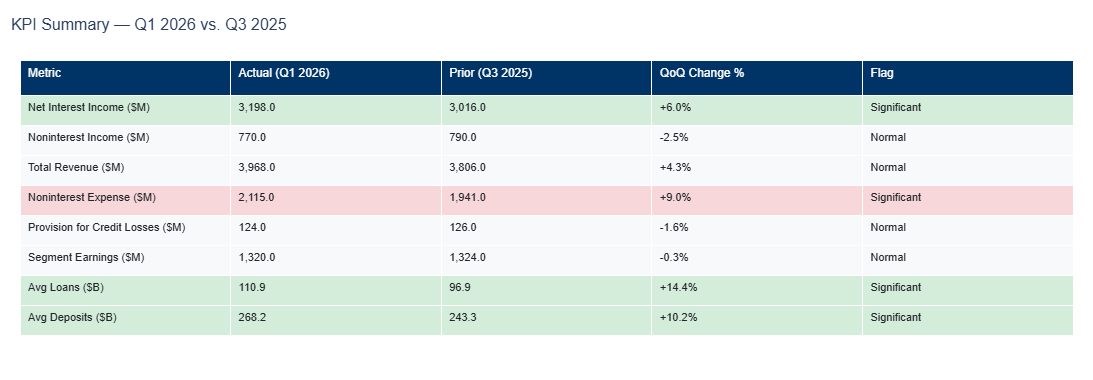

In [16]:
# Visulaization (KPI SUMMARY TABLE)

# This graph allows the manger to understand instantly the pattern due to the color coding but also where to direct their attention by flagging certain columns
# This mirrors the variance summary page in PNC's internal monthly finance reviews.


latest = retail.iloc[-1]  # most recent quarter
prior  = retail.iloc[-2]  # prior quarter for QoQ comparison

kpi_metrics = {
    'net_interest_income':          'Net Interest Income ($M)',
    'noninterest_income':           'Noninterest Income ($M)',
    'total_revenue':                'Total Revenue ($M)',
    'noninterest_expense':          'Noninterest Expense ($M)',
    'provision_for_credit_losses':  'Provision for Credit Losses ($M)',
    'earnings':                     'Segment Earnings ($M)',
    'avg_loans_billions':           'Avg Loans ($B)',
    'avg_deposits_billions':        'Avg Deposits ($B)',
}

# Metrics where a higher value is BAD (expense and credit losses going up = unfavorable)
unfavorable_metrics = ['noninterest_expense', 'provision_for_credit_losses', 'net_loan_charge_offs']

kpi_rows = []
for col, label in kpi_metrics.items():
    actual    = latest[col]
    prior_val = prior[col]
    qoq_pct   = (actual - prior_val) / abs(prior_val) * 100 if prior_val != 0 else 0
    flag      = 'Significant' if abs(qoq_pct) >= MATERIALITY_THRESHOLD else 'Normal'
    is_favorable = (qoq_pct > 0) if col not in unfavorable_metrics else (qoq_pct < 0)
    kpi_rows.append({
        'Metric':           label,
        f'Actual ({latest["period_label"]})': f'{actual:,.1f}',
        f'Prior ({prior["period_label"]})':   f'{prior_val:,.1f}',
        'QoQ Change':       f'{qoq_pct:+.1f}%',
        'Flag':             flag,
        '_pct':             qoq_pct,
        '_favorable':       is_favorable
    })

kpi_df = pd.DataFrame(kpi_rows)

# Build cell color list — green for favorable flagged moves, red for unfavorable
cell_colors = []
for _, row in kpi_df.iterrows():
    if row['Flag'] == 'Significant':
        color = '#d4edda' if row['_favorable'] else '#f8d7da'
    else:
        color = '#f8f9fa'
    cell_colors.append(color)

fig_kpi = go.Figure(data=[go.Table(
    header=dict(
        values=[
            'Metric',
            f'Actual ({latest["period_label"]})',
            f'Prior ({prior["period_label"]})',
            'QoQ Change %',
            'Flag'
        ],
        fill_color='#003366',
        font=dict(color='white', size=12, family='Arial'),
        align='left',
        height=35
    ),
    cells=dict(
        values=[
            kpi_df['Metric'],
            kpi_df[f'Actual ({latest["period_label"]})'],
            kpi_df[f'Prior ({prior["period_label"]})'],
            kpi_df['QoQ Change'],
            kpi_df['Flag']
        ],
        fill_color=[cell_colors] * 5,
        font=dict(color='#212529', size=11, family='Arial'),
        align='left',
        height=30
    )
)])

fig_kpi.update_layout(
    title=dict(
        text=f'KPI Summary — {latest["period_label"]} vs. {prior["period_label"]}',
        font=dict(size=16, family='Arial'),
        x=0.01
    ),
    margin=dict(l=20, r=20, t=60, b=20),
    height=380
)
fig_kpi.show()

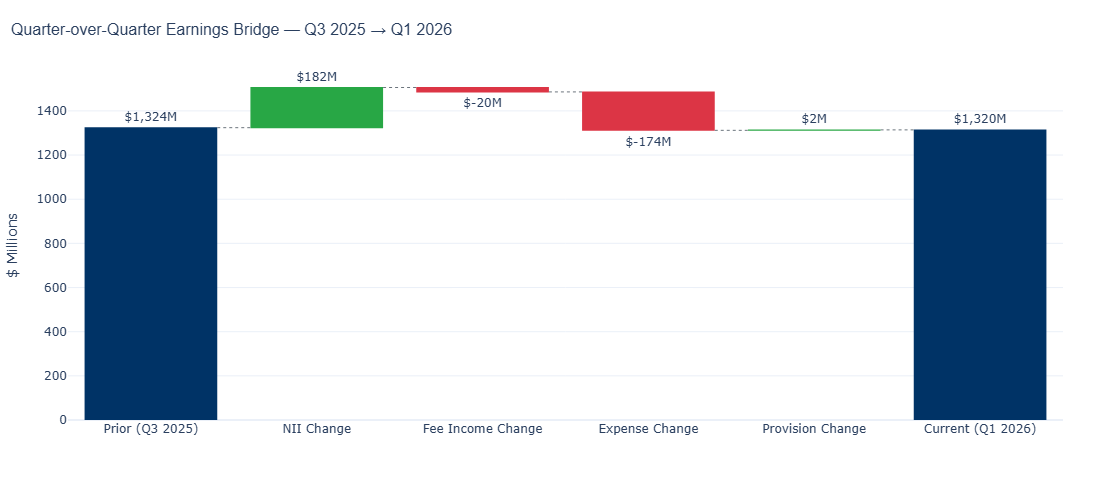

In [18]:
# Visulatization: WATERFALL CHART (QoQ Earnings Bridge)
#
# This graph shows how we got from prior earnings to current earnings.
# Each bar = one line item's contribution to the change in segment earnings.
# This is the standard format for earnings presentations and board decks.
# It answers the CFO's question: "Where exactly did the $X variance come from?"
# Positive changes = green. Negative changes = red. Totals = navy blue.

# Decompose earnings change into its P&L drivers
bridge_items = {
    f'Prior ({prior["period_label"]})':     prior['earnings'],
    'NII Change':                            latest['net_interest_income'] - prior['net_interest_income'],
    'Fee Income Change':                     latest['noninterest_income']  - prior['noninterest_income'],
    # Expense increase = negative earnings impact, so we flip the sign
    'Expense Change':    -(latest['noninterest_expense']          - prior['noninterest_expense']),
    'Provision Change':  -(latest['provision_for_credit_losses']  - prior['provision_for_credit_losses']),
    f'Current ({latest["period_label"]})':  latest['earnings'],
}

# 'absolute' = standalone bar; 'relative' = stacked from running total; 'total' = grand total bar
measure = ['absolute', 'relative', 'relative', 'relative', 'relative', 'total']

fig_waterfall = go.Figure(go.Waterfall(
    name='Earnings Bridge',
    orientation='v',
    measure=measure,
    x=list(bridge_items.keys()),
    y=list(bridge_items.values()),
    text=[f'${v:,.0f}M' for v in bridge_items.values()],
    textposition='outside',
    increasing={'marker': {'color': '#28a745'}},
    decreasing={'marker': {'color': '#dc3545'}},
    totals={'marker':    {'color': '#003366'}},
    connector={'line':   {'color': '#6c757d', 'dash': 'dot', 'width': 1}}
))

fig_waterfall.update_layout(
    title=dict(
        text=f'Quarter-over-Quarter Earnings Bridge — '
             f'{prior["period_label"]} → {latest["period_label"]}',
        font=dict(size=16, family='Arial'),
        x=0.01
    ),
    yaxis_title='$ Millions',
    template='plotly_white',
    height=500,
    showlegend=False,
    margin=dict(l=60, r=30, t=70, b=80)
)
fig_waterfall.show()

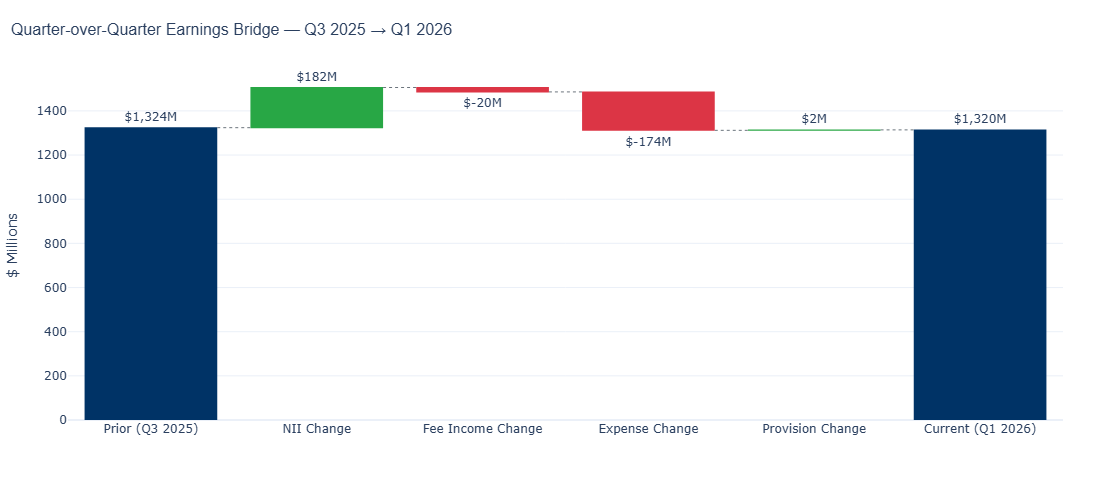

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualizations: WATERFALL CHART (QoQ Earnings Bridge)
#
# This graph shows how we got from prior earnings to current earnings.
# Each bar = one line item's contribution to the change in segment earnings.
# This is the standard format for earnings presentations and board decks.
# It answers the CFO's question: "Where exactly did the $X variance come from?"
# Positive changes = green. Negative changes = red. Totals = navy blue.

# Decompose earnings change into its P&L drivers
bridge_items = {
    f'Prior ({prior["period_label"]})':     prior['earnings'],
    'NII Change':                            latest['net_interest_income'] - prior['net_interest_income'],
    'Fee Income Change':                     latest['noninterest_income']  - prior['noninterest_income'],
    # Expense increase = negative earnings impact, so we flip the sign
    'Expense Change':    -(latest['noninterest_expense']          - prior['noninterest_expense']),
    'Provision Change':  -(latest['provision_for_credit_losses']  - prior['provision_for_credit_losses']),
    f'Current ({latest["period_label"]})':  latest['earnings'],
}

# 'absolute' = standalone bar; 'relative' = stacked from running total; 'total' = grand total bar
measure = ['absolute', 'relative', 'relative', 'relative', 'relative', 'total']

fig_waterfall = go.Figure(go.Waterfall(
    name='Earnings Bridge',
    orientation='v',
    measure=measure,
    x=list(bridge_items.keys()),
    y=list(bridge_items.values()),
    text=[f'${v:,.0f}M' for v in bridge_items.values()],
    textposition='outside',
    increasing={'marker': {'color': '#28a745'}},
    decreasing={'marker': {'color': '#dc3545'}},
    totals={'marker':    {'color': '#003366'}},
    connector={'line':   {'color': '#6c757d', 'dash': 'dot', 'width': 1}}
))

fig_waterfall.update_layout(
    title=dict(
        text=f'Quarter-over-Quarter Earnings Bridge — '
             f'{prior["period_label"]} → {latest["period_label"]}',
        font=dict(size=16, family='Arial'),
        x=0.01
    ),
    yaxis_title='$ Millions',
    template='plotly_white',
    height=500,
    showlegend=False,
    margin=dict(l=60, r=30, t=70, b=80)
)
fig_waterfall.show()

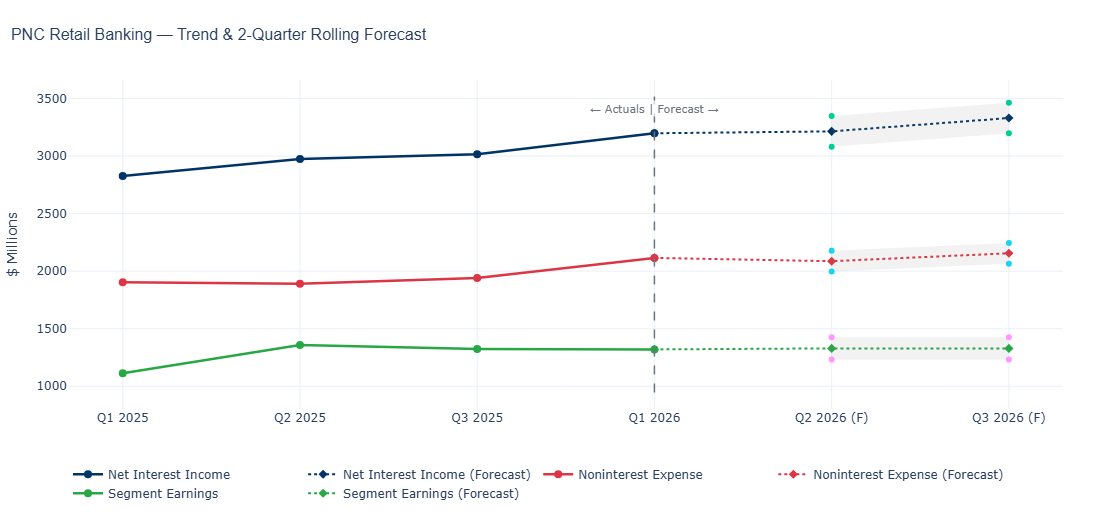

In [22]:
# Visulatization: TREND LINE PANEL WITH FORECAST OVERLAY

# This graph shows us the multi-quarter trajectory of the key P&L lines.
# Solid lines = reported actuals. Dotted lines = 2-quarter forecast.
# Shaded band = ±1 std dev confidence range ("not a point prediction, but a
# range of reasonable outcomes").
# This is the "continuous forecasting" view that PNC's FP&A team uses to
# project run-rate performance and flag when actuals deviate from expectations.

actuals_labels  = retail['period_label'].tolist()
forecast_labels = ['Q2 2026 (F)', 'Q3 2026 (F)']

# All x-axis labels combined (actuals + forecast) for the full chart range
all_labels = actuals_labels + forecast_labels

# Which metrics to plot and their visual styling
trend_metrics = [
    ('net_interest_income', 'Net Interest Income', '#003366'),
    ('noninterest_expense',  'Noninterest Expense', '#dc3545'),
    ('earnings',             'Segment Earnings',    '#28a745'),
]

fig_trend = go.Figure()

for col, label, color in trend_metrics:

    # ACTUALS line — solid with filled markers
    fig_trend.add_trace(go.Scatter(
        x=actuals_labels,
        y=retail[col].tolist(),
        mode='lines+markers',
        name=label,
        line=dict(color=color, width=2.5),
        marker=dict(size=8)
    ))

    # FORECAST extension — bridge from last actual into forecast quarters
    # We start from the last actual point so the lines connect visually
    bridge_x = [actuals_labels[-1]] + forecast_labels
    bridge_y = [retail[col].iloc[-1]] + forecast_results[col]['forecasts']

    fig_trend.add_trace(go.Scatter(
        x=bridge_x,
        y=bridge_y,
        mode='lines+markers',
        name=f'{label} (Forecast)',
        line=dict(color=color, width=2, dash='dot'),
        marker=dict(size=7, symbol='diamond'),
        showlegend=True
    ))

    # CONFIDENCE BAND — shaded polygon between upper and lower bounds
    # Wraps around forecast period only; reversed lower list closes the polygon
    band_x = forecast_labels + forecast_labels[::-1]
    band_y = (
        forecast_results[col]['upper_band'] +
        forecast_results[col]['lower_band'][::-1]
    )
    fig_trend.add_trace(go.Scatter(
        x=band_x,
        y=band_y,
        fill='toself',
        fillcolor='rgba(128,128,128,0.10)',
        line=dict(width=0),
        name=f'{label} ±1σ',
        showlegend=False
    ))

# Creating a maunal line seperator which is drawn as a vertical Scatter trace
# This replaces add_vline() which throws a TypeError on string x-axes.
# We draw a thin grey line at the boundary between actuals and forecast
# by plotting two points at the same x position with a very large y range.

# Find the y-range of all plotted values to size the separator line correctly
all_y_values = (
    retail['net_interest_income'].tolist() +
    retail['noninterest_expense'].tolist() +
    retail['earnings'].tolist()
)
y_min = min(all_y_values) * 0.85   # extend slightly below the lowest value
y_max = max(all_y_values) * 1.10   # extend slightly above the highest value

fig_trend.add_trace(go.Scatter(
    x=[actuals_labels[-1], actuals_labels[-1]],
    y=[y_min, y_max],
    mode='lines',
    line=dict(color='#6c757d', width=1.5, dash='dash'),
    name='Actuals / Forecast boundary',
    showlegend=False
))

# Add a text annotation label near the top of the separator line
fig_trend.add_annotation(
    x=actuals_labels[-1],
    y=y_max * 0.97,
    text='← Actuals | Forecast →',
    showarrow=False,
    font=dict(size=11, color='#6c757d'),
    xanchor='center',
    bgcolor='rgba(255,255,255,0.7)'
)

fig_trend.update_layout(
    title=dict(
        text='PNC Retail Banking — Trend & 2-Quarter Rolling Forecast',
        font=dict(size=16, family='Arial'),
        x=0.01
    ),
    yaxis_title='$ Millions',
    template='plotly_white',
    height=520,
    legend=dict(orientation='h', yanchor='bottom', y=-0.30, xanchor='left', x=0),
    margin=dict(l=60, r=30, t=80, b=110)
)
fig_trend.show()

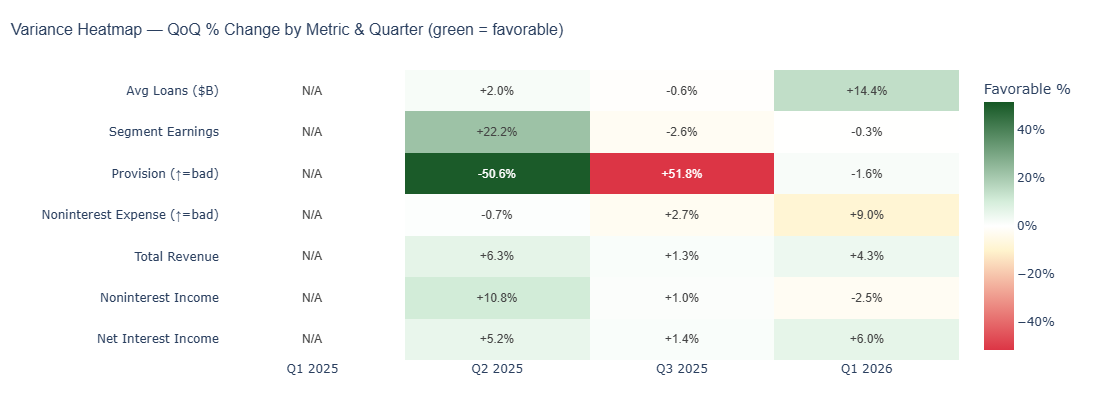

In [23]:
# Visualization: VARIANCE HEATMAP

# This graph makes it easy for a manager scanning multiple quarters at once. 
# Dark green = large favorable variance.
# Dark red = large unfavorable variance. White = near zero change.

# For expense and provision metrics, we invert the color and the logic behind this is that a positive QoQ % change in expense is BAD, so it shows red even
# though the number is positive. This ensures the heatmap always reads green = good, red = bad, regardless of the metric direction.

# This is the format a Senior VP would use to spot patterns across quarters

unfavorable_metrics = ['noninterest_expense', 'provision_for_credit_losses', 'net_loan_charge_offs']

heatmap_metrics = [
    ('net_interest_income',         'Net Interest Income'),
    ('noninterest_income',          'Noninterest Income'),
    ('total_revenue',               'Total Revenue'),
    ('noninterest_expense',         'Noninterest Expense (↑=bad)'),
    ('provision_for_credit_losses', 'Provision (↑=bad)'),
    ('earnings',                    'Segment Earnings'),
    ('avg_loans_billions',          'Avg Loans ($B)'),
]

heatmap_z, heatmap_text, metric_labels = [], [], []
quarter_labels = retail['period_label'].tolist()

for col, label in heatmap_metrics:
    row_z, row_text = [], []
    for i in range(len(retail)):
        pct_col = f'{col}_qoq_pct'
        val = variance_df[pct_col].iloc[i] if pct_col in variance_df.columns else np.nan
        # Invert color direction for unfavorable metrics so heatmap always reads green=good
        display_val = (-val if col in unfavorable_metrics and pd.notnull(val) else val)
        row_z.append(display_val if pd.notnull(display_val) else 0)
        row_text.append(f'{val:+.1f}%' if pd.notnull(val) else 'N/A')
    heatmap_z.append(row_z)
    heatmap_text.append(row_text)
    metric_labels.append(label)

fig_heatmap = go.Figure(data=go.Heatmap(
    z=heatmap_z,
    x=quarter_labels,
    y=metric_labels,
    text=heatmap_text,
    texttemplate='%{text}',
    textfont=dict(size=12, family='Arial'),
    colorscale=[
        [0.0,  '#dc3545'],
        [0.40, '#fff3cd'],
        [0.50, '#ffffff'],
        [0.60, '#d4edda'],
        [1.0,  '#155724'],
    ],
    zmid=0,
    colorbar=dict(title='Favorable %', ticksuffix='%')
))

fig_heatmap.update_layout(
    title=dict(
        text='Variance Heatmap — QoQ % Change by Metric & Quarter (green = favorable)',
        font=dict(size=16, family='Arial'),
        x=0.01
    ),
    template='plotly_white',
    height=420,
    margin=dict(l=220, r=120, t=70, b=60)
)
fig_heatmap.show()

In [25]:
# Report


# WWhy is this section important?
# Finance teams operate under audit and regulatory scrutiny. Every analysis must
# be reproducible and traceable. A timestamped CSV is the "working paper" —
# if a regulator or internal audit asks "what were the Q2 2025 variances?",
# the team produces the exact file that backed the decision.
# This also eliminates the manual Excel copy-paste step that causes errors.

# The export includes: actuals + QoQ/YoY variances + flags + commentary + forecasts
# — everything in one file that any Excel user can open and filter.

export_rows = []

for i, row in retail.iterrows():
    export_row = {
        'period_label': row['period_label'],
        'quarter':      row['quarter'],
    }

    # Actuals
    for col in key_metrics + ['total_revenue', 'efficiency_ratio']:
        export_row[f'actual_{col}'] = row[col]

    # Variances from variance_df
    vrow = variance_df[variance_df['period_label'] == row['period_label']]
    if len(vrow) > 0:
        vrow = vrow.iloc[0]
        for metric in key_metrics:
            export_row[f'{metric}_qoq_chg'] = vrow.get(f'{metric}_qoq_change', np.nan)
            export_row[f'{metric}_qoq_pct'] = vrow.get(f'{metric}_qoq_pct',    np.nan)
            export_row[f'{metric}_yoy_chg'] = vrow.get(f'{metric}_yoy_change', np.nan)
            export_row[f'{metric}_yoy_pct'] = vrow.get(f'{metric}_yoy_pct',    np.nan)

    # Flags and commentary
    period_flags    = flags_df[flags_df['period_label'] == row['period_label']]
    flagged_metrics = period_flags[period_flags['flag'] == 'Significant']['metric'].tolist()
    export_row['flagged_metrics'] = '; '.join(flagged_metrics) if flagged_metrics else 'None'

    all_comments = period_flags[period_flags['flag'] == 'Significant']['commentary'].tolist()
    export_row['commentary'] = ' | '.join(all_comments) if all_comments else ''

    export_rows.append(export_row)

# Append forecast rows at the bottom of the export
forecast_labels_export = ['Q2 2026 (F)', 'Q3 2026 (F)']
for j, flabel in enumerate(forecast_labels_export):
    frow = {'period_label': flabel, 'quarter': f'FORECAST_{j+1}'}
    for metric in forecast_metrics:
        frow[f'forecast_{metric}']       = forecast_results[metric]['forecasts'][j]
        frow[f'forecast_{metric}_upper'] = forecast_results[metric]['upper_band'][j]
        frow[f'forecast_{metric}_lower'] = forecast_results[metric]['lower_band'][j]
    export_rows.append(frow)

master_export_df = pd.DataFrame(export_rows)

# Timestamped filename — each export is uniquely identifiable for audit trail
timestamp       = datetime.now().strftime('%Y%m%d_%H%M')
export_filename = f'PNC_Retail_Variance_Report_{timestamp}.csv'

master_export_df.to_csv(export_filename, index=False)
print(f"✅ Audit-ready export saved: {export_filename}")
print(f"   Rows: {len(master_export_df)} | Columns: {len(master_export_df.columns)}")
print()
master_export_df[[
    'period_label', 'quarter',
    'actual_net_interest_income', 'actual_earnings', 'flagged_metrics'
]].head(10)


✅ Audit-ready export saved: PNC_Retail_Variance_Report_20260420_0957.csv
   Rows: 6 | Columns: 63



,period_label,quarter,actual_net_interest_income,actual_earnings,flagged_metrics
0,Q1 2025,2025Q1,2826.00,1112.00,None
1,Q2 2025,2025Q2,2974.00,1359.00,net_interest_income; noninterest_income; total...
2,Q3 2025,2025Q3,3016.00,1324.00,provision_for_credit_losses
3,Q1 2026,2026Q1,3198.00,1320.00,net_interest_income; noninterest_expense; avg_...
4,Q2 2026 (F),FORECAST_1,NaN,NaN,NaN
5,Q3 2026 (F),FORECAST_2,NaN,NaN,NaN


 Cell In[26], line 3
    The complete Streamlit app is in `app.py` (provided separately). Run it locally with:
        ^
SyntaxError: invalid syntax

## Section 9 — Deployment Instructions

See the README.md file and the step-by-step guide for full deployment instructions.

## Section 10 — README Template

See README.md in the project folder.

## Resume Bullet Generator

After running the notebook, fill in the bracketed values with your actual output numbers:

**Bullet 1 — Variance Analysis:**
Built a Python-based quarterly variance analysis engine for PNC's Retail Banking segment using 4 quarters of real earnings data; automated plus or minus 5% materiality flagging across 8 KPIs and generated plain-English commentary for [X] significant variances.

**Bullet 2 — Forecasting:**
Developed a weighted moving average forecast model (50/30/20 recency weighting plus linear trend adjustment) projecting 2 forward quarters of NII, total revenue, and segment earnings with plus or minus 1 standard deviation confidence bands.

**Bullet 3 — Dashboard and Delivery:**
Deployed a live Streamlit executive dashboard featuring KPI delta cards, a QoQ earnings waterfall bridge, multi-metric trend lines with 2-quarter forecast overlay, and a variance heatmap with one-click audit-ready CSV export.